In [1]:
cd /home/yang1641/PINNACLE/finetune_pinnacle

/home/yang1641/PINNACLE/finetune_pinnacle


In [17]:
import pandas as pd
import numpy as np
import os, wandb, random

from setup import create_parser, get_hparams, setup_paths
from read_data import load_data
from train_utils import training_and_validation
from metrics_utils import get_metrics, save_torch_train_val_preds, save_results
from data_prep import process_and_split_data

import torch
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.utils import shuffle
os.environ['OPENBLAS_NUM_THREADS'] = '1'

import glob
import json

In [42]:
import pandas as pd
%matplotlib inline
import matplotlib.pyplot as plt

from functools import reduce

In [3]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_colwidth', None)  # To display full content of each column

In [4]:
# see https://github.com/mims-harvard/PINNACLE/blob/main/pinnacle/run_pinnacle.sh
# and https://github.com/mims-harvard/PINNACLE/blob/main/pinnacle/parse_args.py


args_manual = {
    'actn':'relu', 
    'batch_size': None, 
    'data_split_path': '/scratch/gilbreth/yang1641/exome/data/PINNACLE/therapeutic_target_task/data_split_EFO_0003767', 
    'dropout': 0.4,  
    'embed': 'try2', 
#     'embed': 'pinnacle',
    'embeddings_dir': '/scratch/gilbreth/yang1641/exome/results/pinnacle/reproduce/epoch250/', 
#     'embeddings_dir': '/scratch/gilbreth/yang1641/exome/data/PINNACLE/pinnacle_embeds/',
    'hidden_dim_1': 32, 
    'hidden_dim_2': 8, 
    'hidden_dim_3': 0, 
    'lr': 0.001, 
#     'metrics_output_dir': '/scratch/gilbreth/yang1641/exome/results/pinnacle/reproduce/epoch250/tmp_evaluation_results', 
    'metrics_output_dir': '/scratch/gilbreth/yang1641/exome/results/pinnacle/reproduce/download_embed/',
#     'models_output_dir': '/scratch/gilbreth/yang1641/exome/results/pinnacle/reproduce/epoch250/tmp_model_outputs', 
    'models_output_dir': '/scratch/gilbreth/yang1641/exome/results/pinnacle/reproduce/download_embed/',
    'negative_proteins_prefix':'/scratch/gilbreth/yang1641/exome/data/PINNACLE/therapeutic_target_task/negative_proteins_EFO_0003767', 
    'norm':'ln', 
    'num_epoch':2000, 
    'order':'nd', 
    'overwrite':False, 
    'positive_proteins_prefix':'/scratch/gilbreth/yang1641/exome/data/PINNACLE/therapeutic_target_task/positive_proteins_EFO_0003767', 
    'random':False, 
    'random_state':100, 
    'task_name':'EFO_0003767', 
    'train_size':0.6, 'val_size':0.2, 
    'wd':0.0001, 'weigh_loss':False, 'weigh_sample':False
              }

## define a function to run the finetune for 10 times

In [5]:
def update_args_output_dir(args):
    args.metrics_output_dir = '/'.join((args.metrics_output_dir.split('/'))[:-1] + [args.task_name] + ['tmp_evaluation_results', ''])
    args.models_output_dir = '/'.join((args.models_output_dir.split('/'))[:-1] + [args.task_name] + ['tmp_model_outputs', ''])
    os.makedirs(args.metrics_output_dir, exist_ok = True)
    os.makedirs(args.models_output_dir, exist_ok = True)
    return args

In [6]:
import argparse

# Convert dictionary to argparse Namespace
args = argparse.Namespace(**args_manual)

args = update_args_output_dir(args)

print(args)

Namespace(actn='relu', batch_size=None, data_split_path='/scratch/gilbreth/yang1641/exome/data/PINNACLE/therapeutic_target_task/data_split_EFO_0003767', dropout=0.4, embed='try2', embeddings_dir='/scratch/gilbreth/yang1641/exome/results/pinnacle/reproduce/epoch250/', hidden_dim_1=32, hidden_dim_2=8, hidden_dim_3=0, lr=0.001, metrics_output_dir='/scratch/gilbreth/yang1641/exome/results/pinnacle/reproduce/download_embed/EFO_0003767/tmp_evaluation_results/', models_output_dir='/scratch/gilbreth/yang1641/exome/results/pinnacle/reproduce/download_embed/EFO_0003767/tmp_model_outputs/', negative_proteins_prefix='/scratch/gilbreth/yang1641/exome/data/PINNACLE/therapeutic_target_task/negative_proteins_EFO_0003767', norm='ln', num_epoch=2000, order='nd', overwrite=False, positive_proteins_prefix='/scratch/gilbreth/yang1641/exome/data/PINNACLE/therapeutic_target_task/positive_proteins_EFO_0003767', random=False, random_state=100, task_name='EFO_0003767', train_size=0.6, val_size=0.2, wd=0.0001, w

# distribution of drug targets in context ai cell types

In [7]:
args.positive_proteins_prefix

'/scratch/gilbreth/yang1641/exome/data/PINNACLE/therapeutic_target_task/positive_proteins_EFO_0003767'

In [11]:
args.task_name

'EFO_0003767'

In [10]:
os.listdir('/'.join(args.positive_proteins_prefix.split('/')[:-1]))

['disease_drug_evidence_EFO_0003767.csv',
 'data_split_EFO_0003767.json',
 'data_split_EFO_0003767_name.json',
 'raw_targets_EFO_0003767.json',
 'raw_targets_EFO_0000685.json',
 'positive_proteins_EFO_0003767.json',
 'negative_proteins_EFO_0003767.json',
 'all_approved_oct2022.csv',
 'data_split_EFO_0000685_name.json',
 'positive_proteins_EFO_0000685.json',
 'disease_drug_evidence_EFO_0000685.csv',
 'negative_proteins_EFO_0000685.json',
 'data_split_EFO_0000685.json']

In [14]:
glob.glob(args.positive_proteins_prefix + '*')

['/scratch/gilbreth/yang1641/exome/data/PINNACLE/therapeutic_target_task/positive_proteins_EFO_0003767.json']

In [15]:
glob.glob(args.negative_proteins_prefix + '*')

['/scratch/gilbreth/yang1641/exome/data/PINNACLE/therapeutic_target_task/negative_proteins_EFO_0003767.json']

### distribution of positive labels (drug targets)

In [18]:
with open(glob.glob(args.positive_proteins_prefix + '*')[0], 'r') as file:
    pos_protein = json.load(file)
    # Process the data
    print(pos_protein)

{'EFO_0003767': {'epithelial cell of lacrimal sac': ['ADORA2B', 'PTGS2', 'PRKCI', 'CHRM3', 'ACHE', 'IL1RL2', 'GABRA2', 'HRH1', 'GABRB3', 'IL6', 'MMP1', 'SCN2A', 'XDH', 'IL1RAP'], 'fast muscle cell': ['PDE4D', 'CUL4A', 'RARB', 'SCN4A', 'PRKCQ', 'GHR'], 'regulatory t cell': ['PRKCH', 'PPIA', 'PRKCA', 'SELPLG', 'PRKCB', 'NR3C1', 'CD40LG', 'ITGA4', 'OPRM1', 'ADORA2A', 'PDE4B', 'ITGB7', 'PRKCQ', 'IL23A', 'TXK', 'JAK1', 'CD3E', 'IL2RA', 'JAK3', 'ITK', 'IFNAR2', 'S1PR4'], 'cardiac muscle cell': ['HMGCR', 'RBX1', 'PRKCI', 'PPIA', 'SIGMAR1', 'S1PR1', 'CRBN', 'DHFR', 'TYK2', 'DDB1', 'FKBP1A', 'NCBP2'], 'conjunctival epithelial cell': ['ADORA2B', 'RBX1', 'PTGS2', 'ALOX5', 'PRKCI', 'PPIA', 'CUL4A', 'PRKCD', 'DDB1', 'MMP1', 'NCBP2', 'IL1RAP'], 'myometrial cell': ['PTGS2', 'JAK2', 'ICAM1', 'PPIA', 'RARA', 'SCN3A', 'PRKCA', 'SMAD7', 'CNR1', 'HRH1', 'RARB', 'IL6', 'MMP1', 'FKBP1A', 'S1PR3', 'PRKD1', 'SCN2A'], 'large intestine goblet cell': ['ACHE', 'SMAD7', 'PRKCG', 'PRKCA', 'PPARG', 'HRH1', 'PRKCZ', 

In [20]:
print(len(pos_protein))
print(pos_protein.keys())

1
dict_keys(['EFO_0003767'])


In [21]:
pos_protein = pos_protein[args.task_name]
print(len(pos_protein))

157


In [22]:
pos_protein_summary = pd.DataFrame(list(pos_protein.items()), columns=['cell', 'positive'])
print(pos_protein_summary.shape)
pos_protein_summary.head()

(157, 2)


,cell,positive
0,epithelial cell of lacrimal sac,"[ADORA2B, PTGS2, PRKCI, CHRM3, ACHE, IL1RL2, GABRA2, HRH1, GABRB3, IL6, MMP1, SCN2A, XDH, IL1RAP]"
1,fast muscle cell,"[PDE4D, CUL4A, RARB, SCN4A, PRKCQ, GHR]"
2,regulatory t cell,"[PRKCH, PPIA, PRKCA, SELPLG, PRKCB, NR3C1, CD40LG, ITGA4, OPRM1, ADORA2A, PDE4B, ITGB7, PRKCQ, IL23A, TXK, JAK1, CD3E, IL2RA, JAK3, ITK, IFNAR2, S1PR4]"
3,cardiac muscle cell,"[HMGCR, RBX1, PRKCI, PPIA, SIGMAR1, S1PR1, CRBN, DHFR, TYK2, DDB1, FKBP1A, NCBP2]"
4,conjunctival epithelial cell,"[ADORA2B, RBX1, PTGS2, ALOX5, PRKCI, PPIA, CUL4A, PRKCD, DDB1, MMP1, NCBP2, IL1RAP]"


In [24]:
pos_protein_summary = pd.merge(
    pos_protein_summary, 
    pd.DataFrame([(key, len(value)) for key, value in pos_protein.items()], columns=['cell', 'num_positive'])
)
pos_protein_summary.head()

,cell,positive,num_positive
0,epithelial cell of lacrimal sac,"[ADORA2B, PTGS2, PRKCI, CHRM3, ACHE, IL1RL2, GABRA2, HRH1, GABRB3, IL6, MMP1, SCN2A, XDH, IL1RAP]",14
1,fast muscle cell,"[PDE4D, CUL4A, RARB, SCN4A, PRKCQ, GHR]",6
2,regulatory t cell,"[PRKCH, PPIA, PRKCA, SELPLG, PRKCB, NR3C1, CD40LG, ITGA4, OPRM1, ADORA2A, PDE4B, ITGB7, PRKCQ, IL23A, TXK, JAK1, CD3E, IL2RA, JAK3, ITK, IFNAR2, S1PR4]",22
3,cardiac muscle cell,"[HMGCR, RBX1, PRKCI, PPIA, SIGMAR1, S1PR1, CRBN, DHFR, TYK2, DDB1, FKBP1A, NCBP2]",12
4,conjunctival epithelial cell,"[ADORA2B, RBX1, PTGS2, ALOX5, PRKCI, PPIA, CUL4A, PRKCD, DDB1, MMP1, NCBP2, IL1RAP]",12


In [25]:
pos_protein_summary.describe()

,num_positive
count,157.000000
mean,17.375796
std,10.310198
min,6.000000
25%,11.000000
50%,15.000000
75%,22.000000
max,114.000000


<Figure size 600x600 with 0 Axes>

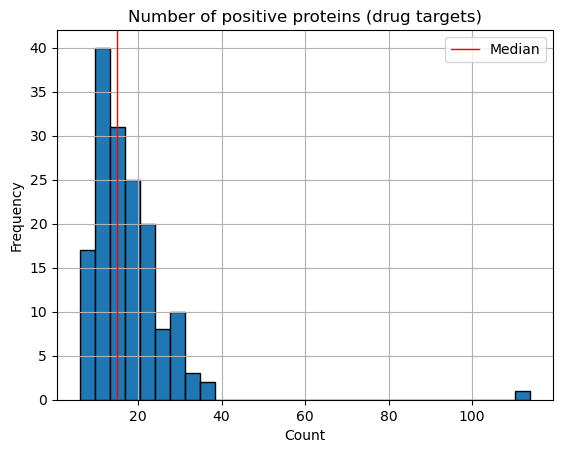

In [45]:
# Create the scatter plot
plt.figure(figsize=(6, 6))  # Adjust figure size if needed

# Plot df1
hist = pos_protein_summary.hist(bins=30, edgecolor='black', linewidth=1)

plt.axvline(np.median(pos_protein_summary[['num_positive']]), 
            color='red', linestyle='solid', linewidth=1, label='Median')


# Add labels and title
plt.xlabel('Count')
plt.ylabel('Frequency')
plt.title('Number of positive proteins (drug targets)')

# Add legend
plt.legend()

# Show the plot
plt.grid(True)
plt.show()

### distribution of negative labels (not drug targets)

In [38]:
with open(glob.glob(args.negative_proteins_prefix + '*')[0], 'r') as file:
    neg_protein = json.load(file)
    # Process the data
    print(neg_protein)

{'EFO_0003767': {'epithelial cell of lacrimal sac': ['CASP3', 'ALDH1A3', 'ANXA2', 'ACTG1', 'HP', 'SNAP25', 'SERPINA3', 'ABCB11', 'TRPV4', 'TUBB4A', 'JUP', 'PRDX1', 'CDK7', 'TYR', 'GLS', 'SFRP4', 'RPE65', 'MDM2', 'MAP4K5', 'PLA2G2A', 'CDC42BPG', 'PON1', 'DDR2', 'HSPA8', 'FRK', 'DLG4', 'SOD3', 'PLAT', 'LYZ', 'CTPS1', 'KCNK1', 'ENO1', 'IGFBP3', 'PLD1', 'MAT2A', 'SULT2B1', 'AZGP1', 'RIOK3', 'ASPG', 'CA8', 'ABCA1', 'LCN1', 'NOMO1', 'S100A1', 'LIMK1', 'CYP1B1', 'CAMK2B', 'KCNJ3', 'RXRG', 'KCNMA1', 'F3', 'RHO', 'YES1', 'DDR1', 'CAST', 'SLK', 'FGF1', 'ATP1A1', 'RORB', 'SERPINF1', 'DMD', 'STK3', 'TUBA4A', 'PNP', 'S100B', 'SGK1', 'NTRK1', 'MT-CO3', 'TP73', 'PLIN3', 'TOP1', 'LDHA', 'TF', 'MAP4K4', 'CDK15', 'GSTO2', 'MARK1', 'COX7A1', 'HTATIP2', 'PRNP', 'GPX2', 'STK38L', 'DSP', 'REN', 'TUBB4B', 'MYLK', 'LTK', 'KRT14', 'APOD', 'DGKG', 'GABBR1', 'GSTP1', 'SLC25A4', 'PYCR1', 'GLP1R', 'EPHA4', 'ATF3', 'YARS2', 'ATP6V1C2', 'MAPK10', 'NEK1', 'GLDC', 'HSPA5', 'LDLR', 'PSAT1', 'NECTIN4', 'CACNB4', 'KRT16'

In [39]:
neg_protein = neg_protein[args.task_name]
print(len(neg_protein))

157


In [40]:
neg_protein_summary = pd.DataFrame(list(neg_protein.items()), columns=['cell', 'negative'])
print(neg_protein_summary.shape)
neg_protein_summary.head()

(157, 2)


,cell,negative
0,epithelial cell of lacrimal sac,"[CASP3, ALDH1A3, ANXA2, ACTG1, HP, SNAP25, SERPINA3, ABCB11, TRPV4, TUBB4A, JUP, PRDX1, CDK7, TYR, GLS, SFRP4, RPE65, MDM2, MAP4K5, PLA2G2A, CDC42BPG, PON1, DDR2, HSPA8, FRK, DLG4, SOD3, PLAT, LYZ, CTPS1, KCNK1, ENO1, IGFBP3, PLD1, MAT2A, SULT2B1, AZGP1, RIOK3, ASPG, CA8, ABCA1, LCN1, NOMO1, S100A1, LIMK1, CYP1B1, CAMK2B, KCNJ3, RXRG, KCNMA1, F3, RHO, YES1, DDR1, CAST, SLK, FGF1, ATP1A1, RORB, SERPINF1, DMD, STK3, TUBA4A, PNP, S100B, SGK1, NTRK1, MT-CO3, TP73, PLIN3, TOP1, LDHA, TF, MAP4K4, CDK15, GSTO2, MARK1, COX7A1, HTATIP2, PRNP, GPX2, STK38L, DSP, REN, TUBB4B, MYLK, LTK, KRT14, APOD, DGKG, GABBR1, GSTP1, SLC25A4, PYCR1, GLP1R, EPHA4, ATF3, YARS2, ATP6V1C2, MAPK10, ...]"
1,fast muscle cell,"[COX4I1, QDPR, ALDH6A1, HSD17B10, GOT1, CDK16, PSPH, MDM2, ACADS, SDHD, MTHFD1, SYT2, PRKAA2, GLRX2, GRIK1, RPL35, TUBG1, PYGM, RXRA, ACADM, PHKG1, PSMB5, KEAP1, CHRNA1, NOMO1, S100A1, VDAC1, MDH1, PDHA1, CAMK2B, RXRG, COX5A, DLAT, MAPT, FNTA, DDR1, HDAC4, SERPINF1, DMD, IDH2, TUBA4A, CACNB1, RYR1, TP73, RPL23A, PLIN3, TNNC1, LDHA, ATP1A2, BAAT, GPD1, SCN3B, CACNG1, MAOB, TNNC2, CYCS, COX7A1, DYRK1B, PGR, DAPK2, COX6A2, ALDH4A1, EPHB1, GAPDH, CASQ2, PRKAB2, LTK, COQ8A, SLC25A12, SLC25A4, IMPA2, ADCY1, GOT2, ALDOA, THRA, SLC7A8, ACAD8, AIFM1, MDH2, FABP7, ACACB, FNTB, SLC12A4, DAPK3, MAPK4, CIB2, KCNQ5, COX7B, SDHA, ACTA1, ACY1, COX6C, MAPK12, NOS1, HAGH, PEBP1, FARS2, CDKN1A, CKMT2, EGLN1, ...]"
2,regulatory t cell,"[CASP3, PSMB8, SHMT2, COX4I1, ACTG1, HLA-A, DGKQ, KCNN4, PSMB10, IRAK4, DGKA, GLS, VAMP1, HSPA8, TNFRSF1B, GNG2, PIM1, BDH1, CIT, MR1, RPS6, CLK3, DYRK1A, EEF1A1, GRB2, STK38, RPS19, MAP4K2, GSTM1, RPL14, CMTR1, PTK2B, HMMR, SLC16A7, HDAC4, RPS5, CDK1, RPS28, BIRC5, TUBA4A, MINK1, CD44, ATP6V0C, CD247, MAP3K1, EEF2, CSK, CMPK1, CYCS, ATF1, HTATIP2, STK24, SLC38A1, CPNE1, LDHB, RPS6KA1, SNRPD2, ZYX, B2M, SFPQ, COQ8A, ALDOA, MAPK13, NEK1, TOP2A, STK10, HP1BP3, HMOX2, BECN1, HNRNPD, NEK2, CREB1, GPHN, CAMK2D, PLK1, LIG1, HNRNPL, RPL10, DGKH, PTGES3, M6PR, TNFRSF8, FARS2, HABP4, PKMYT1, TUBA1A, PAK2, RORA, HNRNPH3, CLK1, ODC1, TLK1, PIK3CG, RPS13, MTHFD2, CALM1, LATS1, RACK1, RPL18, MAP4K1, ...]"
3,cardiac muscle cell,"[JUP, MAPK1, SDHD, RAC1, PRKAA2, GFER, STIP1, GLRX2, TARS2, HIPK3, ACADM, RPS19, COX5A, ATP1A1, XPO1, RPS28, GCAT, MT-CO3, PLIN3, TNNC1, ACAA2, TOP1, LDHA, ALAS1, PEF1, MARK4, BMPR2, DHCR7, HIPK2, LDHB, PRKAB2, SLC25A12, GANAB, RDH14, EBP, HMOX2, BECN1, HNRNPD, COX6C, GMPS, WEE1, PPP2CA, TUBB, TUBA1A, MAP1A, HNRNPH3, ALDH7A1, CYB5A, NSDHL, NPPB, TRAPPC3, GSTK1, MTR, PLEKHA1, RPS2, HADHA, C1QBP, ESRRG, CPE, RPSA, KCNH2, IDH3B, PPP2CB, EPOR, COX6B1, CCS, IDH3A, PTK2, SLC8A1, PSMB2, POLE4, COX4I1, QDPR, TOP2B, HSD17B10, CDK16, FARSB, ACADS, NME1, ITPA, SLC25A13, ENO1, EPHB2, HMGB1, HSP90B1, PDHA1, RXRG, FNTA, DMD, ARF1, MOCS2, CYCS, GLO1, RANBP1, COX6A2, ALDH4A1, VEGFB, GABBR1, SFPQ, GOT2, ...]"
4,conjunctival epithelial cell,"[JUP, DGKA, MARK3, EPHA4, GLS, MDM2, AKR1A1, FRK, SDHD, RAC1, PRKAA2, KCNK1, STIP1, COX5A, CSNK1A1, ATP1A1, CSAD, STK3, MT-CO3, PLIN3, TOP1, LDHA, PEF1, GSTO2, MARK4, MKNK2, GPX2, STK38L, KRT14, PI4KB, EBP, PDXK, HP1BP3, BECN1, HNRNPD, CACNB4, COX6C, DGKH, ARG2, WEE1, PPP2CA, CDKN1A, IL1A, HSD17B4, CFH, HNRNPH3, ALDH7A1, CLK1, BLVRB, CALM1, NSDHL, TRAPPC3, SF1, NOLC1, GSTK1, ATP2B4, MTAP, SERPINB2, GCLC, PLK3, C1QBP, CP, COMT, ETFDH, FDXR, S100A4, PPP2CB, COX6B1, ATF6, EPHA1, MAP3K4, IDH3A, GSS, UGCG, CKMT1A, PRPF4B, PTK2, AKR1C1, PSMB2, TXNRD1, MARK2, HDAC5, HSD17B10, CDK7, CDK16, GAK, MAP4K5, PLA2G2A, NME1, ITPA, CTPS1, ENO1, IGFBP3, SULT2B1, CA8, CROT, KCNMA1, RHO, SERPINF1, ARF1, ...]"


In [ ]:
reduce(lambda x, y: x.merge(y, on='cell'), output_summary_df_lst)

In [43]:
protein_summary = reduce(lambda x, y: x.merge(y, on='cell'), 
                        [
    pos_protein_summary, 
    neg_protein_summary, 
    pd.DataFrame([(key, len(value)) for key, value in neg_protein.items()], columns=['cell', 'num_negative'])
]
                        )
protein_summary.head()

,cell,positive,num_positive,negative,num_negative
0,epithelial cell of lacrimal sac,"[ADORA2B, PTGS2, PRKCI, CHRM3, ACHE, IL1RL2, GABRA2, HRH1, GABRB3, IL6, MMP1, SCN2A, XDH, IL1RAP]",14,"[CASP3, ALDH1A3, ANXA2, ACTG1, HP, SNAP25, SERPINA3, ABCB11, TRPV4, TUBB4A, JUP, PRDX1, CDK7, TYR, GLS, SFRP4, RPE65, MDM2, MAP4K5, PLA2G2A, CDC42BPG, PON1, DDR2, HSPA8, FRK, DLG4, SOD3, PLAT, LYZ, CTPS1, KCNK1, ENO1, IGFBP3, PLD1, MAT2A, SULT2B1, AZGP1, RIOK3, ASPG, CA8, ABCA1, LCN1, NOMO1, S100A1, LIMK1, CYP1B1, CAMK2B, KCNJ3, RXRG, KCNMA1, F3, RHO, YES1, DDR1, CAST, SLK, FGF1, ATP1A1, RORB, SERPINF1, DMD, STK3, TUBA4A, PNP, S100B, SGK1, NTRK1, MT-CO3, TP73, PLIN3, TOP1, LDHA, TF, MAP4K4, CDK15, GSTO2, MARK1, COX7A1, HTATIP2, PRNP, GPX2, STK38L, DSP, REN, TUBB4B, MYLK, LTK, KRT14, APOD, DGKG, GABBR1, GSTP1, SLC25A4, PYCR1, GLP1R, EPHA4, ATF3, YARS2, ATP6V1C2, MAPK10, ...]",223
1,fast muscle cell,"[PDE4D, CUL4A, RARB, SCN4A, PRKCQ, GHR]",6,"[COX4I1, QDPR, ALDH6A1, HSD17B10, GOT1, CDK16, PSPH, MDM2, ACADS, SDHD, MTHFD1, SYT2, PRKAA2, GLRX2, GRIK1, RPL35, TUBG1, PYGM, RXRA, ACADM, PHKG1, PSMB5, KEAP1, CHRNA1, NOMO1, S100A1, VDAC1, MDH1, PDHA1, CAMK2B, RXRG, COX5A, DLAT, MAPT, FNTA, DDR1, HDAC4, SERPINF1, DMD, IDH2, TUBA4A, CACNB1, RYR1, TP73, RPL23A, PLIN3, TNNC1, LDHA, ATP1A2, BAAT, GPD1, SCN3B, CACNG1, MAOB, TNNC2, CYCS, COX7A1, DYRK1B, PGR, DAPK2, COX6A2, ALDH4A1, EPHB1, GAPDH, CASQ2, PRKAB2, LTK, COQ8A, SLC25A12, SLC25A4, IMPA2, ADCY1, GOT2, ALDOA, THRA, SLC7A8, ACAD8, AIFM1, MDH2, FABP7, ACACB, FNTB, SLC12A4, DAPK3, MAPK4, CIB2, KCNQ5, COX7B, SDHA, ACTA1, ACY1, COX6C, MAPK12, NOS1, HAGH, PEBP1, FARS2, CDKN1A, CKMT2, EGLN1, ...]",174
2,regulatory t cell,"[PRKCH, PPIA, PRKCA, SELPLG, PRKCB, NR3C1, CD40LG, ITGA4, OPRM1, ADORA2A, PDE4B, ITGB7, PRKCQ, IL23A, TXK, JAK1, CD3E, IL2RA, JAK3, ITK, IFNAR2, S1PR4]",22,"[CASP3, PSMB8, SHMT2, COX4I1, ACTG1, HLA-A, DGKQ, KCNN4, PSMB10, IRAK4, DGKA, GLS, VAMP1, HSPA8, TNFRSF1B, GNG2, PIM1, BDH1, CIT, MR1, RPS6, CLK3, DYRK1A, EEF1A1, GRB2, STK38, RPS19, MAP4K2, GSTM1, RPL14, CMTR1, PTK2B, HMMR, SLC16A7, HDAC4, RPS5, CDK1, RPS28, BIRC5, TUBA4A, MINK1, CD44, ATP6V0C, CD247, MAP3K1, EEF2, CSK, CMPK1, CYCS, ATF1, HTATIP2, STK24, SLC38A1, CPNE1, LDHB, RPS6KA1, SNRPD2, ZYX, B2M, SFPQ, COQ8A, ALDOA, MAPK13, NEK1, TOP2A, STK10, HP1BP3, HMOX2, BECN1, HNRNPD, NEK2, CREB1, GPHN, CAMK2D, PLK1, LIG1, HNRNPL, RPL10, DGKH, PTGES3, M6PR, TNFRSF8, FARS2, HABP4, PKMYT1, TUBA1A, PAK2, RORA, HNRNPH3, CLK1, ODC1, TLK1, PIK3CG, RPS13, MTHFD2, CALM1, LATS1, RACK1, RPL18, MAP4K1, ...]",160
3,cardiac muscle cell,"[HMGCR, RBX1, PRKCI, PPIA, SIGMAR1, S1PR1, CRBN, DHFR, TYK2, DDB1, FKBP1A, NCBP2]",12,"[JUP, MAPK1, SDHD, RAC1, PRKAA2, GFER, STIP1, GLRX2, TARS2, HIPK3, ACADM, RPS19, COX5A, ATP1A1, XPO1, RPS28, GCAT, MT-CO3, PLIN3, TNNC1, ACAA2, TOP1, LDHA, ALAS1, PEF1, MARK4, BMPR2, DHCR7, HIPK2, LDHB, PRKAB2, SLC25A12, GANAB, RDH14, EBP, HMOX2, BECN1, HNRNPD, COX6C, GMPS, WEE1, PPP2CA, TUBB, TUBA1A, MAP1A, HNRNPH3, ALDH7A1, CYB5A, NSDHL, NPPB, TRAPPC3, GSTK1, MTR, PLEKHA1, RPS2, HADHA, C1QBP, ESRRG, CPE, RPSA, KCNH2, IDH3B, PPP2CB, EPOR, COX6B1, CCS, IDH3A, PTK2, SLC8A1, PSMB2, POLE4, COX4I1, QDPR, TOP2B, HSD17B10, CDK16, FARSB, ACADS, NME1, ITPA, SLC25A13, ENO1, EPHB2, HMGB1, HSP90B1, PDHA1, RXRG, FNTA, DMD, ARF1, MOCS2, CYCS, GLO1, RANBP1, COX6A2, ALDH4A1, VEGFB, GABBR1, SFPQ, GOT2, ...]",368
4,conjunctival epithelial cell,"[ADORA2B, RBX1, PTGS2, ALOX5, PRKCI, PPIA, CUL4A, PRKCD, DDB1, MMP1, NCBP2, IL1RAP]",12,"[JUP, DGKA, MARK3, EPHA4, GLS, MDM2, AKR1A1, FRK, SDHD, RAC1, PRKAA2, KCNK1, STIP1, COX5A, CSNK1A1, ATP1A1, CSAD, STK3, MT-CO3, PLIN3, TOP1, LDHA, PEF1, GSTO2, MARK4, MKNK2, GPX2, STK38L, KRT14, PI4KB, EBP, PDXK, HP1BP3, BECN1, HNRNPD, CACNB4, COX6C, DGKH, ARG2, WEE1, PPP2CA, CDKN1A, IL1A, HSD17B4, CFH, HNRNPH3, ALDH7A1, CLK1, BLVRB, CALM1, NSDHL, TRAPPC3, SF1, NOLC1, GSTK1, ATP2B4, MTAP, SERPINB2, GCLC, PLK3, C1QBP, CP, COMT, ETFDH, FDXR, S100A4, PPP2CB, COX6B1, ATF6, EPHA1, MAP3K4, IDH3A, GSS, UGCG, CKMT1A, PRPF4B, PTK2, A

In [44]:
protein_summary.describe()

,num_positive,num_negative
count,157.000000,157.000000
mean,17.375796,285.394904
std,10.310198,122.246323
min,6.000000,70.000000
25%,11.000000,223.000000
50%,15.000000,300.000000
75%,22.000000,344.000000
max,114.000000,1377.000000


In [50]:
protein_summary.columns

Index(['cell', 'positive', 'num_positive', 'negative', 'num_negative'], dtype='object')

num_positive
num_negative


<Figure size 600x600 with 0 Axes>

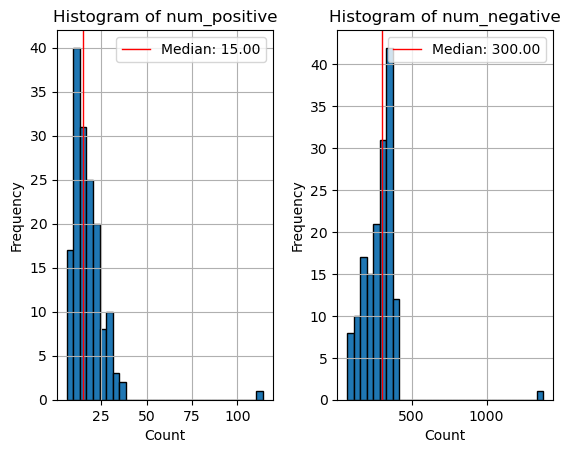

In [53]:
# Create the scatter plot
plt.figure(figsize=(6, 6))  # Adjust figure size if needed

# Plot df1
hist = protein_summary.hist(bins=30, edgecolor='black', linewidth=1)

# plt.axvline(np.median(pos_protein_summary[['num_negative']]), 
#             color='red', linestyle='solid', linewidth=1, label='Median')

for ax in hist.flatten():
    column = ax.get_title()  # The title of the subplot is the column name
    print(column)
    median = protein_summary[column].median()
    ax.axvline(median, color='red', linestyle='solid', linewidth=1, label=f'Median: {median:.2f}')
    ax.legend()
    ax.set_xlabel('Count')
    ax.set_ylabel('Frequency')
    ax.set_title(f'Histogram of {column}', fontsize=12)
    
# Add legend
plt.legend()

# Show the plot
plt.grid(True)
plt.show()

### drug-protein data of IBD

## TODO: 

check https://github.com/mims-harvard/PINNACLE/blob/e3d2fced3bb812141e76a947351e25fbafb7ce6b/evaluate/evaluate_target_prioritization.py#L150

for the use of disease_drug_evidence_EFO_0003767.csv

In [58]:
protein_summary[['num_positive']].sum()

num_positive    2728
dtype: int64

In [61]:
protein_drug = pd.read_csv('/scratch/gilbreth/yang1641/exome/data/PINNACLE/therapeutic_target_task/' + 
                           'disease_drug_evidence_EFO_0003767.csv', 
                          sep = '\t')
print(protein_drug.shape)
protein_drug.head()

(1718, 8)


,diseaseFromSourceMappedId,diseaseId,targetId,targetFromSourceId,clinicalPhase,clinicalStatus,drugId,targetId_genename
0,EFO_0007149,EFO_0007149,ENSG00000007314,P35499,4,Completed,DB00297,SCN4A
1,EFO_0007149,EFO_0007149,ENSG00000007314,P35499,4,Recruiting,DB00281,SCN4A
2,EFO_0000729,EFO_0000729,ENSG00000010671,Q06187,2,Completed,DB14924,BTK
3,EFO_0003767,EFO_0003767,ENSG00000011677,P34903,4,Completed,DB00818,GABRA3
4,EFO_0003767,EFO_0003767,ENSG00000011677,P34903,4,Completed,DB00683,GABRA3


In [65]:
protein_drug[['diseaseFromSourceMappedId']]

,diseaseFromSourceMappedId
0,EFO_0007149
1,EFO_0007149
2,EFO_0000729
3,EFO_0003767
4,EFO_0003767
5,EFO_0000729
6,EFO_0000384
7,EFO_0000729
8,EFO_0000729
9,EFO_0000384


## repeat for RA

In [54]:
args.task_name

'EFO_0003767'

In [67]:
with open('/scratch/gilbreth/yang1641/exome/data/PINNACLE/therapeutic_target_task/' + 'positive_proteins_EFO_0000685.json', 'r') as file:
    pos_protein = json.load(file)['EFO_0000685']
    # Process the data
#     print(pos_protein)

In [68]:
with open('/scratch/gilbreth/yang1641/exome/data/PINNACLE/therapeutic_target_task/' + 'negative_proteins_EFO_0000685.json', 'r') as file:
    neg_protein = json.load(file)['EFO_0000685']
    # Process the data
#     print(neg_protein)

In [70]:
protein_summary = reduce(lambda x, y: x.merge(y, on='cell'), 
                        [
                            pd.DataFrame(list(pos_protein.items()), columns=['cell', 'positive']), 
                            pd.DataFrame([(key, len(value)) for key, value in pos_protein.items()], columns=['cell', 'num_posistive']),
                            pd.DataFrame(list(neg_protein.items()), columns=['cell', 'negative']), 
                            pd.DataFrame([(key, len(value)) for key, value in neg_protein.items()], columns=['cell', 'num_negative'])
]
                        )
protein_summary.head()

,cell,positive,num_posistive,negative,num_negative
0,epithelial cell of lacrimal sac,"[IL6, ITGAV, TUBB6, FGFR3, PDE9A, PDE6A, PDE6B, LTB4R, PTGS2, ESR2, PDE3A, HRH1, TUBB4B, NOS2, MIF, PDE1C, KIT, SCN2A, TUBB2A, TUBB4A, TUBB1, TUBB2B, TUBB3]",23,"[STMN4, COMT, DSP, ACTG1, LIMK1, ATF4, KRT10, SLC16A4, MARK1, SCN1B, SLC25A4, PON1, CKB, CFI, NCS1, GLS, KRT14, PSAT1, CAMK2B, DGKI, TXNRD1, S100A6, IGFBP3, ABCB1, S100A2, ADH7, MAP4K5, F3, ALDH3A1, KCNK1, TYR, COX7A1, XDH, S100A13, HTATIP2, ATP6V1C2, ERBB4, KCNB1, L1CAM, GLUL, GSTO2, RIPK4, SNAP25, HSD17B2, TOP1, GJA1, ANXA1, CTNNB1, IL1A, FGF1, ABCB11, HSPA5, FGF2, GUCY1A1, REN, BRAF, FGFR1, MGST1, PRDX1, KCNMA1, ITGB1, BDNF, NEK1, SERPINF1, MT3, VEGFA, PLA2G2A, ASPH, F2R, RDH8, RIOK3, KRT7, TRAPPC3, GLDC, AZGP1, LTF, DLG4, MAP2K3, ALDH7A1, CASP3, MT-CO1, STK35, CLU, ABCA1, ALK, FRK, NQO1, GSTP1, NUAK2, MT1A, SULT2B1, EPAS1, EPCAM, CKMT1A, CHRM3, CARTPT, P3H3, TGM2, PYCR1, PLD1, ...]",221
1,fast muscle cell,"[PDE5A, POLD2, PDE4D, CUL4A, KEAP1, SCN4A, MAP2K2, POLE3]",8,"[QDPR, TNNC2, ACY1, GOT2, GLRX2, CKMT2, SOD1, MAP4, PSMB5, PEBP1, SLC25A4, SCN1B, PHYH, CKB, OGDH, CALM1, MGST3, COX6A2, PDHA1, ECHS1, ADCY1, CIB2, CAMK2B, GAPDH, HADHA, FARS2, GSTM4, PRDX2, GPI, TPM1, DAPK3, MAOB, PSPH, COX7A1, S100A13, CKM, ERBB4, COX6C, CHP1, COX5A, FNTA, RAF1, THRA, GP1BA, TPT1, PHKG1, KCNJ12, PRKAG3, DYRK1B, KCNC1, NNT, SERPINF1, TPI1, KCNC2, ASPH, COX8A, ACSL1, RPL35, CYB5R1, SLC29A2, HDAC11, HSD17B10, SYT2, CRAT, DCLK2, MUSK, GRIK1, COX5B, AIFM1, IDH3G, THRB, FNTB, TUBG1, HADH, RXRA, MDH2, ALDH4A1, SDHA, CAMK2A, MDH1, ACTA1, EGF, ACSS2, SCN3B, SOD2, BAAT, ACADM, COX7C, LTK, CACNB1, SLC12A4, FTH1, ABCC9, RORA, IDH2, HOXA10, NQO2, NPR2, COX6B1, MAPK4, ...]",172
2,regulatory t cell,"[CD4, PPIA, LTB, NR3C1, CD2, ITK, SELPLG, OPRM1, POLD4, POLE3, JAK1, TRAF3IP2, PTGER4, RRM1, PIK3CD, PDE9A, CD40LG, PDE6B, IRAK4, TXK, PIK3CG, PRIM2, POLD1, ESR2, JAK3, IL6R, PDE3B, PRIM1, LTA, POLE, MIF, PDE6D, ITGAL, PDE4B, IL23A, PDE7A]",36,"[RPS6KA1, TNIK, HABP4, ACTG1, DDX5, ITGB7, ATP6V0C, MAPK13, CASK, SOD1, RPL4, ODC1, OGDH, CIT, GLS, LSM6, CALM1, CDK17, RPL10, IGHA1, IGHG4, PTGES3, ATF1, FARS2, RIC3, PSME1, PSMB10, RPS6KA3, TNFRSF1B, RPS6, EGLN2, TNFRSF8, STAT5B, HTATIP2, GPX7, NCF4, TESMIN, DNMT3A, TOP2A, LAYN, OGFOD2, RPS2, PLK4, RPS5, TSHR, IKBKE, KCNN4, CPNE1, DGKA, BECN1, TPT1, RPS8, PKMYT1, PRKCA, ELOVL5, TUBA1A, RPS28, HNRNPD, MAP4K1, RACK1, YWHAB, NEK1, GSTK1, PTPN4, CALM3, SHMT2, LIG1, EZH2, MAP4K2, CREB1, LATS1, CASP3, TLK1, ZYX, IFNAR2, MAP3K1, CASP1, BDH1, HNRNPL, CCR4, DGKZ, TTK, DDX39B, RPSA, F5, LDHB, AAK1, MYH9, MTR, HDAC1, PDK1, GNG2, RPL18, ATIC, DGKH, CD79B, STK10, STK39, DYRK1A, PLK3, ...]",181
3,cardiac muscle cell,"[IMPDH2, PPIA, ITGAV, NCBP2, TUBB6, MAP2K2, RBX1, PDE6B, DHFR, MAP2K1, GMPS, FDPS, DDB1, TUBB, HMGCR, POLD2, TUBB4B, MIF, CRBN, TUBB2A, PTH1R, PDE6D, TYK2, FKBP1A]",24,"[TNIK, ITPA, NME1, PSMB5, RDH11, EGLN3, PAK4, PDHA1, ECHS1, PTGES3, HADHA, PRDX2, CDK5, HMGB1, S100A13, FARSA, PHB2, THRA, SRI, CANX, HSPA5, DHCR7, OAZ1, SLC16A1, KHSRP, ITGB1, ERBB2, VCAN, IVD, CCS, ASPH, TRAPPC3, CASP3, MT-CO1, HSD17B10, ATP2A2, RPSA, PSMB2, C1QBP, MTR, PDK1, HADH, CSNK1E, PYGB, MDH2, ABCC5, ALDH4A1, PPP2CA, MAPK6, PPP2CB, ESRRG, VLDLR, ENO1, PCYT1A, IDH2, PDIA3, EPOR, BMPR2, VWF, RTCB, SCO1, CYB5A, ALDH3A2, METAP2, PRKAB2, CACNA1C, ADCY5, SLC25A12, PIP4K2B, RPS19, FDX1, IDH3A, HNRNPA2B1, ACADSB, CARS2, MAPK9, GCAT, PGK1, DMD, PRKCI, MT-ATP6, COX7B, CDK4, VAMP2, IGFBP7, PYGM, ALDH6A1, RFK, HIBADH, GSK3B, PPARA, KCNQ5, IDH3B, DLAT, PSMB1, VKORC1L1, PRKAG1, GOT2, GLRX2, KRT10, ...]",381
4,conjunctival epithelial cell,"[PPIA, ITGAV, NCBP2, TUBB6, POLE3, TRAF3IP2, RBX1, RRM1, FGFR3, PDE6A, CUL4A, LTB4R, PTGS2, DDB1, IL6R, ALOX5, POLD2, TUBB4B, NOS2, MIF, TUBB2A, IL1R1]",22,"[ACTG1, ITPA, CSNK2A2, NME1, PSMB5, EGLN3, CALM1, PAK4, ECHS1, ACVR1B, PTGES3, TXNRD1, PRDX2, RPS6KA3, S100A2, ADH7, MAP4K5, SPTLC2, F3, MME, COX7A1, S100A13, HTATIP2, CBR1, SPTLC1, KCNN4, CES1, RIPK4, IL1A, HSPA5, KHSRP, ITGB

In [ ]:
# Create the scatter plot
plt.figure(figsize=(6, 6))  # Adjust figure size if needed

# Plot df1
hist = protein_summary.hist(bins=30, edgecolor='black', linewidth=1)

for ax in hist.flatten():
    column = ax.get_title()  # The title of the subplot is the column name
    print(column)
    median = protein_summary[column].median()
    ax.axvline(median, color='red', linestyle='solid', linewidth=1, label=f'Median: {median:.2f}')
    ax.legend()
    ax.set_xlabel('Count')
    ax.set_ylabel('Frequency')
    ax.set_title(f'Histogram of {column}', fontsize=12)
    
# Add legend
plt.legend()

# Show the plot
plt.grid(True)
plt.show()

num_posistive
num_negative


<Figure size 600x600 with 0 Axes>